## Introdução: 
O preço das passagens aéreas muda o tempo todo e pode variar bastante, o faz esse tema ser interessante para tentar predizer o preço através de outros fatores. No nosso Dataset temos informações sobre vôos entre diversas cidades da Índia, sendo os preditores: a companhia aérea, o trajeto entre as cidades de origem e destino, a classe escolhida, o número de escalas, a duração do voo e a antecedência com que a passagem é comprada. O desafio é entender como cada um desses aspectos pesa na hora de definir quanto o passageiro vai pagar no final.



## Análise Exploratória: 


In [ ]:
# Importando bibliotecas

import numpy as np
import pandas as pd
import altair as alt
import vegafusion
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import geodatasets
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable, get_cmap


### Importando base de dados (Flight)

In [29]:
df_flight = pd.read_csv("flight.csv")

df_flight.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [ ]:
# Removendo a primeira coluna, pois não acrescenta na análise

df_flight = df_flight.drop('Unnamed: 0',axis=1)

In [ ]:
# Informações
df_flight.info()

# Verificar valores nulos
df_flight.isnull().sum()

Aqui podemos observar que não temos valores nulos a serem tratados.

## Colunas

As colunas existentes no dataset escolhido são:  

1. **airline** – Companhia aérea responsável pelo voo.  

2. **flight** – Código ou número identificador do voo.  

3. **source_city** – Cidade de origem de onde o voo parte.  

4. **departure_time** – Faixa de horário da decolagem (por exemplo: manhã, tarde, noite).  

5. **stops** – Número de paradas intermediárias (ex: zero, one, two_or_more).  

6. **arrival_time** – Faixa de horário de chegada ao destino.  

7. **destination_city** – Cidade de destino para onde o voo está indo.  

8. **class** – Classe da passagem (por exemplo: Economy, Business).  

9. **duration** – Duração total do voo em horas.  

10. **days_left** – Quantidade de dias restantes até a data do voo no momento da coleta dos dados.  

11. **price** – Preço da passagem aérea.


## Resumo Estatístico

### Análise unidimensional

Principais medidas unidimensionias das variáveis numéricas:

In [ ]:
df_flight.describe()

#### Histogramas

In [ ]:
# Pela quantidade de observações, é necessário desabilitar o máximo de colunas padrão do Altair (5000)

alt.data_transformers.disable_max_rows()


#### Histogramas das variáveis numéricas

In [ ]:
num_cols = ["duration", "days_left", "price"]

charts = [
    alt.Chart(df_flight).mark_bar().encode(
        alt.X(col, type="quantitative", bin=alt.BinParams(maxbins=15), title=col),
        alt.Y("count()", type="quantitative", title="Contagem de ocorrências")
    ).properties(width=150, height=150)
    for col in num_cols
]

histogramas_num = alt.hconcat(*charts).properties(
    title="Distribuição de variáveis numéricas"
)

histogramas_num

#### Histogramas das variáveis categóricas

In [ ]:
cat_cols = [
    "airline", "source_city", "departure_time", "stops",
    "arrival_time", "destination_city", "class"
]
charts_cat = [
    alt.Chart(df_flight).mark_bar().encode(
        x=alt.X(col, type="nominal", title=col, sort='-y'),
        y=alt.Y("count()", type="quantitative", title="Contagem de ocorrências"),
        tooltip=[col, "count()"]
    ).properties(width=150, height=150)
    for col in cat_cols
]

# organiza os gráficos em uma grade
histogramas_cat = alt.hconcat(*charts_cat[:4]).resolve_scale(y='independent')
if len(cat_cols) > 4:
    row2 = alt.hconcat(*charts_cat[4:]).resolve_scale(y='independent')
    histogramas_cat = alt.vconcat(histogramas_cat, row2)

histogramas_cat = histogramas_cat.properties(
    title="Distribuição de variáveis categóricas"
)

histogramas_cat


#### Boxplots para as variáveis numéricas

In [ ]:
col_titles = {
    "duration": "Duração do voo (horas)",
    "days_left": "Dias restantes até o voo",
    "price": "Preço da passagem (R$)"
}


plt.figure(figsize=(15, 4))

# cria um boxplot horizontal para cada variável numérica
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1) 
    sns.boxplot(x=df_flight[col])  
    plt.title(f"Boxplot de {col_titles[col]}")
    plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## Análise Bidimensional


Vamos começar por um mapa de calor entre as variáveis numéricas:

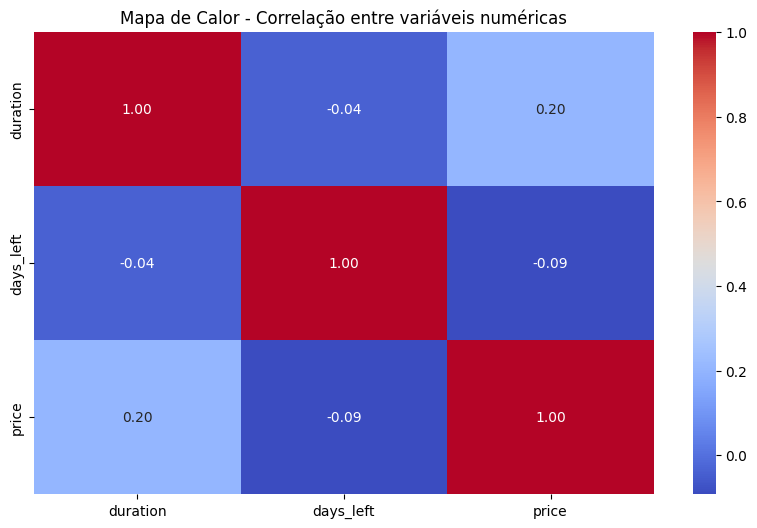

In [4]:
num_cols = ["duration", "days_left", "price"]

plt.figure(figsize=(10, 6))
sns.heatmap(df_flight[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Calor - Correlação entre variáveis numéricas')
plt.show()

Uma pergunta válida é como o preço varia com as companhias aéreas:

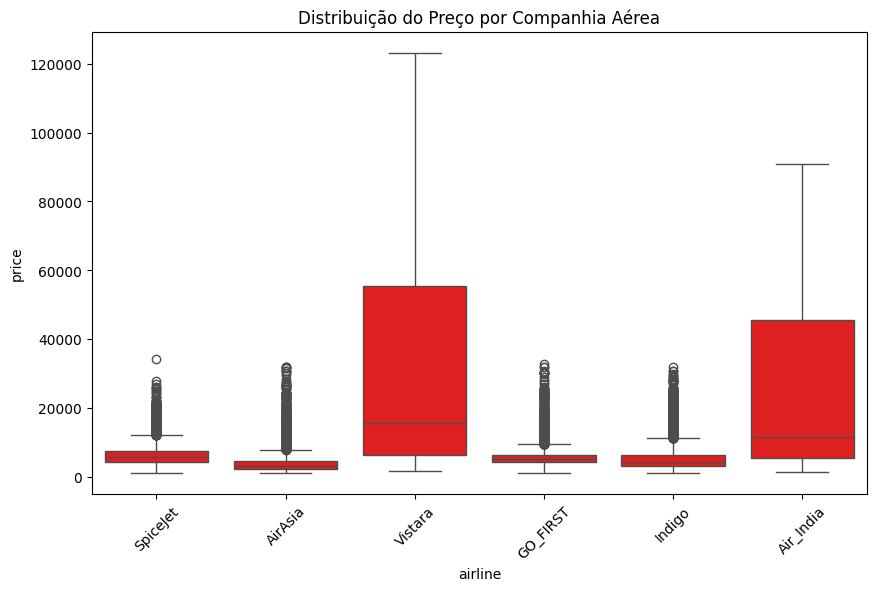

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_flight, x='airline', y='price',color= 'red')
plt.title('Distribuição do Preço por Companhia Aérea')
plt.xticks(rotation=45)
plt.show()


Outra pergunta é como o preço varia entre os tempos de chegada e partida.

In [30]:
departure_price = df_flight.groupby('departure_time')['price'].mean().reset_index()
departure_price

,departure_time,price
0,Afternoon,18179.203331
1,Early_Morning,20370.676718
2,Evening,21232.361894
3,Late_Night,9295.299387
4,Morning,21630.760254
5,Night,23062.146808


In [32]:
arrival_price = df_flight.groupby('arrival_time')['price'].mean().reset_index()
arrival_price

,arrival_time,price
0,Afternoon,18494.598993
1,Early_Morning,14993.139521
2,Evening,23044.371615
3,Late_Night,11284.906078
4,Morning,22231.076098
5,Night,21586.758341


C:\Users\danie\AppData\Local\Temp\ipykernel_40324\600857098.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\danie\AppData\Local\Temp\ipykernel_40324\600857098.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


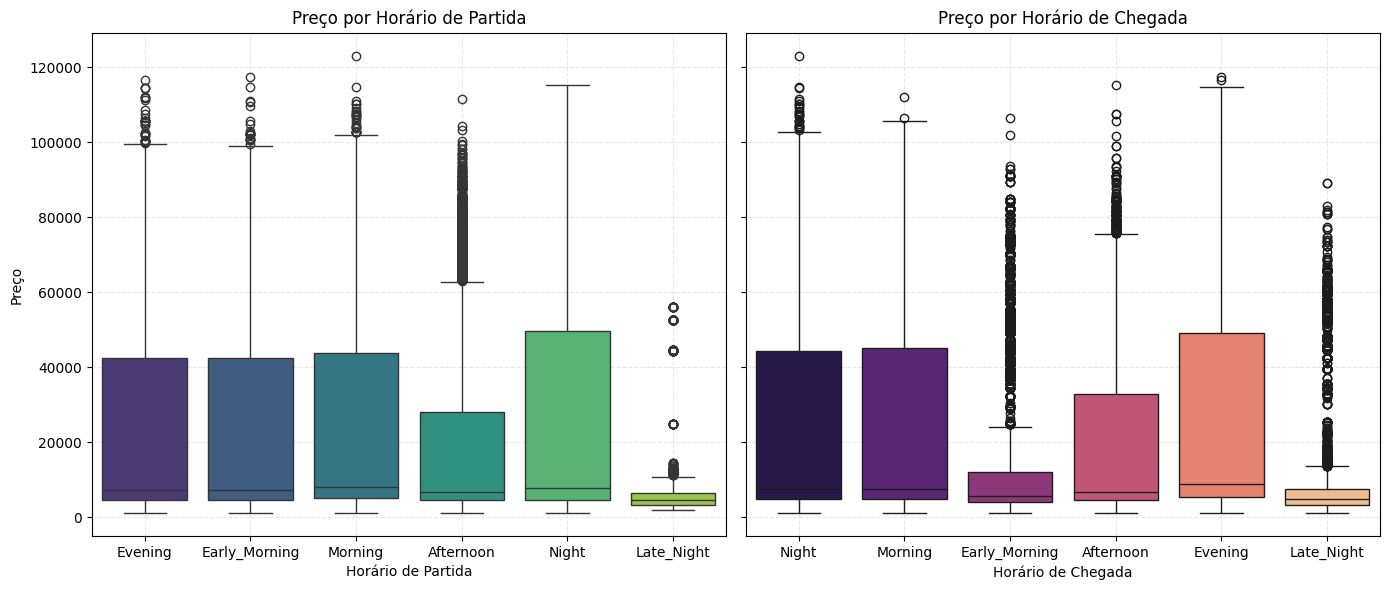

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Partida
sns.boxplot(
    data=df_flight,
    x='departure_time',
    y='price',
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title('Preço por Horário de Partida')
axes[0].set_xlabel('Horário de Partida')
axes[0].set_ylabel('Preço')
axes[0].grid(True, linestyle='--', alpha=0.3)

# Chegada
sns.boxplot(
    data=df_flight,
    x='arrival_time',
    y='price',
    palette='magma',
    ax=axes[1]
)
axes[1].set_title('Preço por Horário de Chegada')
axes[1].set_xlabel('Horário de Chegada')
axes[1].set_ylabel('')
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Agora vamos tentar juntar essas informações em uma única visualização.

C:\Users\danie\AppData\Local\Temp\ipykernel_40324\4082721803.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  g = sns.relplot(
C:\Users\danie\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128184 (\N{MONEY WITH WINGS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


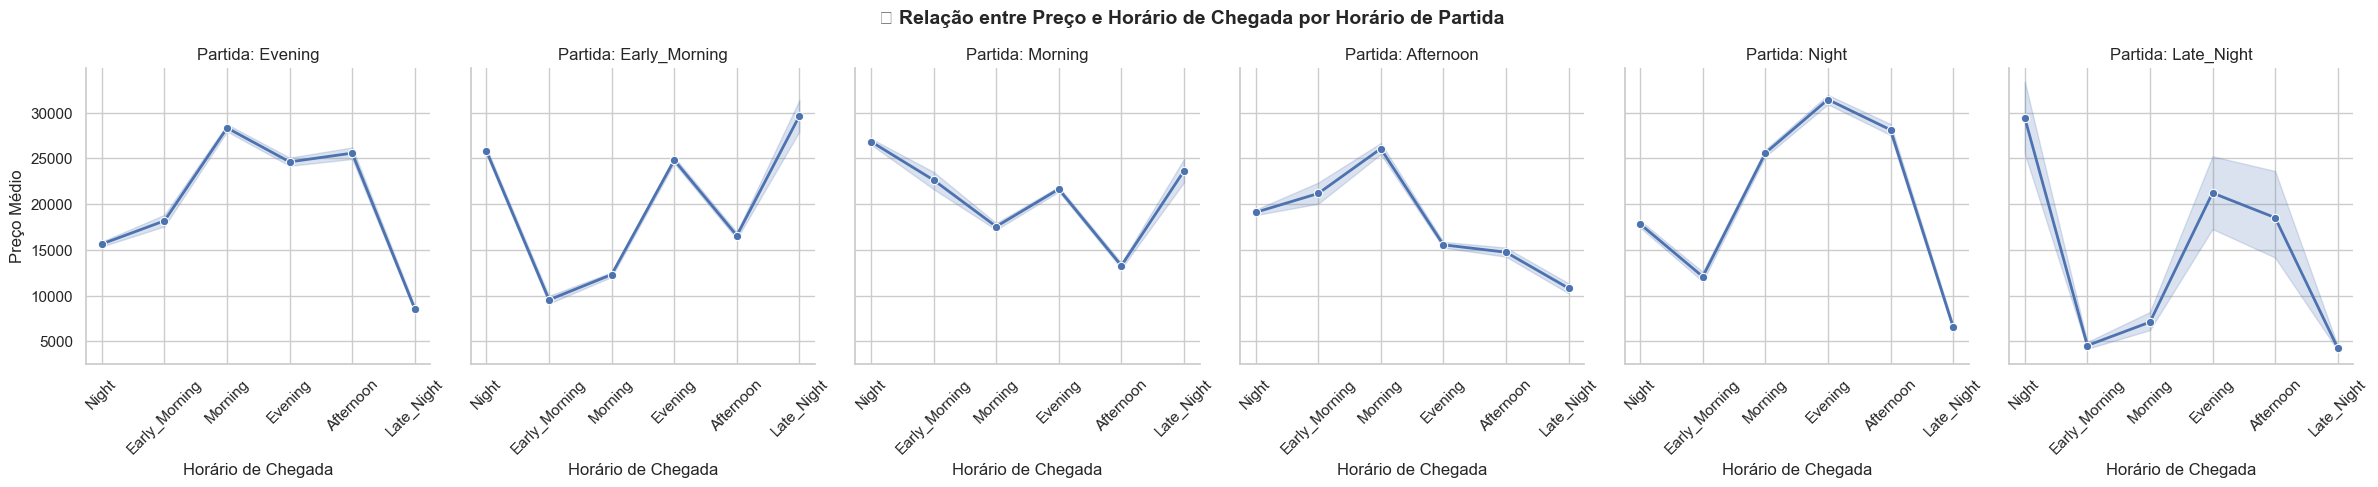

In [37]:
sns.set_theme(style="whitegrid")

g = sns.relplot(
    data=df_flight,
    x="arrival_time",
    y="price",
    col="departure_time",
    kind="line",
    marker="o",
    linewidth=2,
    height=4,
    aspect=1,
    palette="viridis"
)

# Ajustes estéticos
g.set_titles(col_template="Partida: {col_name}")
g.set_axis_labels("Horário de Chegada", "Preço Médio")
g.fig.suptitle("💸 Relação entre Preço e Horário de Chegada por Horário de Partida", 
               fontsize=14, fontweight="bold", y=1.05)

# Rotação dos rótulos do eixo X
for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45)

plt.show()

In [39]:
df_flight["source_city"].unique()

array(['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai'],
      dtype=object)

Nesses gráficos podemos observar a relação entre o o horário de partida e chegada. Com um olhar mais crítico podemos observar a relação entre o preço e o tempo de viagem, além do horário em si. Por exemplo, se o seu vôo sai a tarde e só chega de manhã, significa que teve pelo penos 18h de duração.

Agora vamos analisar como o preço varia entre as cidades.

In [52]:
cities = ['Delhi', 'Mumbai', 'Bangalore', 'Kolkata', 'Hyderabad', 'Chennai']


df_filtered = df_flight[
    df_flight['source_city'].isin(cities) & df_flight['destination_city'].isin(cities)
]


price_matrix = (
    df_filtered.groupby(['source_city', 'destination_city'])['price']
    .mean()
    .unstack()
    .reindex(index=cities, columns=cities)
)


np.fill_diagonal(price_matrix.values, np.nan)


price_matrix.style.background_gradient(cmap="RdYlGn_r", axis=None)\
    .set_caption("Preço Médio das Passagens entre Principais Cidades (₹)")\
    .format("{:.0f}")

destination_city,Delhi,Mumbai,Bangalore,Kolkata,Hyderabad,Chennai
source_city,,,,,,
Delhi,nan,19356,17880,20566,17347,19370
Mumbai,18725,nan,23148,22379,21004,22782
Bangalore,17723,23129,nan,23500,21226,23322
Kolkata,19422,22079,22745,nan,21500,23660
Hyderabad,17244,20081,21347,20824,nan,21848
Chennai,18982,22766,25082,22670,21591,nan


Intuitivamente podemos pensar que um dos principais preditores de preço seja a distância entre as cidades. Para analisar visualmente essa hipótese, vamos plotar um mapa de calor dos preços médios entre as cidades no mapa real da Índia.

C:\Users\danie\AppData\Local\Temp\ipykernel_40324\551301186.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("RdYlGn_r")


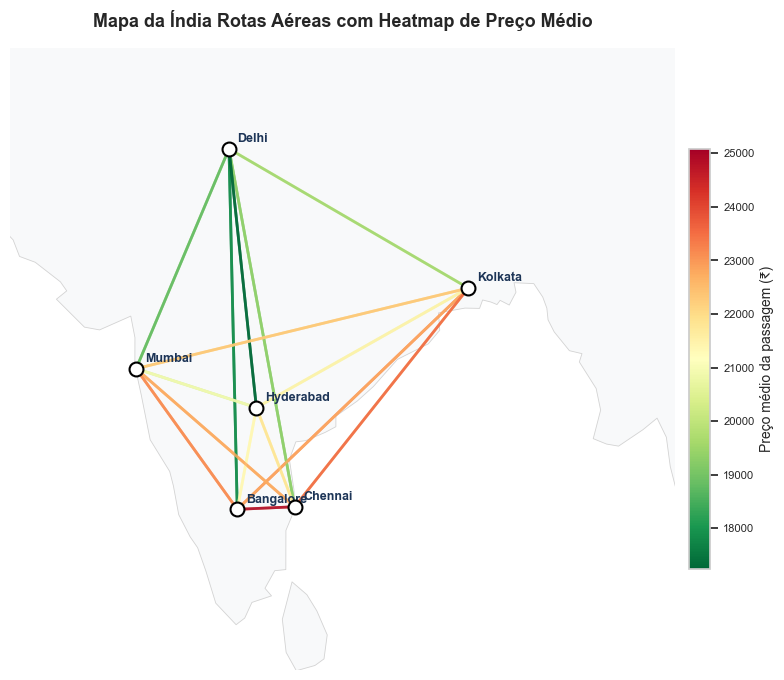

In [53]:

city_coords = {
    'Delhi': (28.6139, 77.2090),
    'Mumbai': (19.0760, 72.8777),
    'Bangalore': (12.9716, 77.5946),
    'Kolkata': (22.5726, 88.3639),
    'Hyderabad': (17.3850, 78.4867),
    'Chennai': (13.0827, 80.2707)
}

def haversine_distance(city1, city2):
    from math import radians, sin, cos, sqrt, atan2
    if city1 not in city_coords or city2 not in city_coords:
        return np.nan
    lat1, lon1 = city_coords[city1]
    lat2, lon2 = city_coords[city2]
    R = 6371
    dlat, dlon = radians(lat2 - lat1), radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))


if 'distance' not in df_flight.columns:
    df_flight['distance'] = df_flight.apply(
        lambda row: haversine_distance(row['source_city'], row['destination_city']),
        axis=1
    )


route_stats = (
    df_flight.groupby(['source_city', 'destination_city'])
    .agg({'price': 'mean', 'distance': 'mean'})
    .reset_index()
)
route_stats['src_lat'] = route_stats['source_city'].map(lambda x: city_coords.get(x, (None, None))[0])
route_stats['src_lon'] = route_stats['source_city'].map(lambda x: city_coords.get(x, (None, None))[1])
route_stats['dst_lat'] = route_stats['destination_city'].map(lambda x: city_coords.get(x, (None, None))[0])
route_stats['dst_lon'] = route_stats['destination_city'].map(lambda x: city_coords.get(x, (None, None))[1])


world_path = geodatasets.get_path("naturalearth.land")
world = gpd.read_file(world_path)
india = world.cx[67:98, 6:37]


fig, ax = plt.subplots(figsize=(8, 8))
india.plot(ax=ax, color="#f8f9fa", edgecolor="lightgray", linewidth=0.6)


cmap = get_cmap("RdYlGn_r")  
norm = Normalize(vmin=route_stats['price'].min(), vmax=route_stats['price'].max())


for _, row in route_stats.iterrows():
    color = cmap(norm(row['price']))
    plt.plot(
        [row['src_lon'], row['dst_lon']],
        [row['src_lat'], row['dst_lat']],
        color=color,
        linewidth=2,
        alpha=0.8,
        zorder=2
    )


for city, (lat, lon) in city_coords.items():
    plt.scatter(lon, lat, s=100, color='white', edgecolors='black', linewidth=1.5, zorder=3)
    plt.text(lon + 0.4, lat + 0.3, city, fontsize=9, fontweight='bold', color='#1d3557')


sm = ScalarMappable(norm=norm, cmap=cmap)
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Preço médio da passagem (₹)', fontsize=10)
cbar.ax.tick_params(labelsize=8)


plt.xlim(67, 98)
plt.ylim(6, 33)
plt.title("Mapa da Índia Rotas Aéreas com Heatmap de Preço Médio", fontsize=13, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
plt.show()


Como podemos ver nossa hipótese não parece verdadeira. Alguns fatores que podem explicar isso são: a demanda de vôos, a frota de aviões disponibilizados pelas comanhias para cada rota entre outros.